In [1]:
import sys
import importlib
def reload_modules(*modules):
    for module in modules:
        if module.__name__ in sys.modules:
            importlib.reload(module)
        else:
            print(f"Module {module.__name__} is not currently imported.")

from magpie_perception import pcd
from magpie_perception import utils
from magpie_perception.utils import label_wrist_image, find_object
from magpie_control import realsense_wrapper as real
from magpie_control import ur5
from magpie_control import gripper
reload_modules(pcd, utils, real, ur5, gripper)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
[Open3D INFO] Resetting default logger to print to terminal.


In [2]:
devices = real.poll_devices()
print(devices)
wrist = real.RealSense(fps=15, w=640, h=480, device_name="D405")
wrist.initConnection(device_serial=devices['D405'])
wkspc = real.RealSense(zMax=5, fps=15, w=640, h=480, device_name="D435")
wkspc.initConnection(device_serial=devices['D435'])

{'D435': '832412070344', 'D405': '126122270157'}
There are 2 available devices!
There are 2 available devices!


In [3]:
importlib.reload(ur5)
importlib.reload(gripper)
ROBOT_IP = "192.168.0.4"
robot = ur5.UR5_Interface(ROBOT_IP, 
                            freq=50, # 6Hz frequency
                            record=False,
                            provide_ft_sensor=True,
                            provide_gripper=True)
robot.start()
robot.start_ft_sensor(poll_rate=100)

Found Dynamixel Port:
/dev/ttyACM0

Succeeded to open the port
Succeeded to change the baudrate
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!


In [4]:
camera_dict = {
    wrist: "record/wrist/",
    wkspc: "record/workspace/"
}

In [5]:
# importlib.reload(gripper)
# G = gripper.Gripper(servoport = '/dev/ttyACM0')
# G.reset_packet_overload()
# import time

# def log_freq(cf_t=[], ft_t=[], robot_log=[], camera_dict={}, dur=1):
#     cf_Hz = len(cf_t) / dur
#     print("Gripper frequency: ", cf_Hz)
#     ft_Hz = len(ft_t) / dur
#     print("FT frequency: ", ft_Hz)
#     ur_Hz = len(robot_log) / dur
#     print("UR5 frequency: ", ur_Hz)
#     if len(camera_dict) > 0:
#         for camera in camera_dict:
#             camera_Hz = len(camera.buffer_dict) / (dur*2)
#             print(f"{camera_dict[camera]}: {camera_Hz} Hz")

In [36]:
# # measure frequency of sensors
import time
import os
# clear out images in record/wrist/, record/workspace/, record/wkspc
for camera in camera_dict:
    if os.path.exists(camera_dict[camera]):
        for filename in os.listdir(camera_dict[camera]):
            file_path = os.path.join(camera_dict[camera], filename)
            try:
                if os.path.isfile(file_path):
                    os.remove(file_path)
            except Exception as e:
                print(f"Error deleting file {file_path}: {e}")

# # create record/robot_log.csv if it doesnt exist and wipe if it does
# if not os.path.exists("record/robot_log.csv"):
#     with open("record/robot_log.csv", "w") as f:
#         f.write("timestamp,actual_q,actual_qd,actual_TCP_pose,actual_TCP_speed\n")    

# import asyncio
# from concurrent.futures import ThreadPoolExecutor
# async def main():
#     G.cf_t = []
#     G.cf_t_ts = []
#     ft_t = []
#     robot_log = {}
#     dur = 3  # or however long you want

#     # Start gripper task in background
#     # gripper_task = asyncio.create_task(G.reset_and_close_gripper_async(duration=dur, record=True))
#     gripper_task = asyncio.create_task(G.reset_and_close_gripper_async(duration=3, record=True))
#     for camera in camera_dict:
#         camera.begin_record(filepath=camera_dict[camera], record_depth=False)
#     start = time.time()
#     # Run polling loop concurrently
#     # robot.recv.startFileRecording("record/robot_log.csv", ["timestamp", "actual_q", "actual_qd", "actual_TCP_pose", "actual_TCP_speed"])
#     while time.time() - start < dur:
#         # print(G.cf_t)
#         ft = robot.get_ft_data()
#         ft_t.append(ft)
#         timestamp = time.time()
#         pose = robot.recv.getActualTCPPose()
#         speed = robot.recv.getActualTCPSpeed()
#         q = robot.recv.getActualQ()
#         qd = robot.recv.getActualQd()
#         robot_log[timestamp] = {
#             "actual_q": q,
#             "actual_qd": qd,
#             "actual_TCP_pose": pose,
#             "actual_TCP_speed": speed,
#             "wrench": ft
#         }
#         robot.ctrl.speedL([0.00, -0.00, -0.000, 0.0, 0.0, 0.0], 0.5, 0.25)
#         await asyncio.sleep(0)  # give control back to event loop

#     await gripper_task

#     G.reset_packet_overload()
#     print("\nFrequency when both polled + robot command + async gripper close + async camera record")
#     cf_t = G.cf_t
#     log_freq(cf_t, ft_t, robot_log, camera_dict, time.time() - start)
#     for camera in camera_dict:
#         await camera.stop_record()

#     return cf_t, ft_t, robot_log

# # Outside your script, run it
# cf, ft, ur = await main()
# robot.stop_recording()
# robot.ctrl.speedL([0.00, -0.00, 0.00, 0.0, 0.0, 0.0], 0.5, 0.25)

In [7]:
# G.reset_packet_overload()
# G.open_gripper()

In [19]:
import numpy as np
motion_plan = np.load("scalingforce/motion_plan.npy", allow_pickle=True).item()
motion_plan

{'position_direction': [1, -1, 0],
 'position_goal': [0.1, 0.05, 0.0],
 'force': [7.5, 5.0, 1.0],
 'grasp_force': 12.5,
 'duration': 3.0}

In [20]:
goal_delta = np.array(motion_plan['position_goal'])
direction = np.array(motion_plan['position_direction'])
sign = np.where(direction < 0, -1, 1)
force = np.array(motion_plan['force']) * sign
wrench_goal = np.hstack((force, np.zeros(3)))
init_cmd = np.hstack((force / -300, np.zeros(3)))
duration = motion_plan['duration']
# duration = 5
grasp_force = motion_plan['grasp_force']
P = 0.0003 # stiffness gain, default is 0.0005

# robot.force_position_control(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, camera_dict=camera_dict,
#                 init_cmd=init_cmd, tolerance=0.01, duration=duration, p=P, control_type="proportional")

motion_log = await robot.force_position_control_async(wrench=wrench_goal, goal_delta=goal_delta, grasp_force=grasp_force, 
                                         camera_dict=camera_dict, init_cmd=init_cmd, tolerance=0.01, 
                                         duration=duration, p=P, control_type="bang_bang")



D405 Recording Started
D435 Recording Started
Error reading from OptoForce!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
[RxPacketError] Overload error!
D405 Recording Task Cancelled
D405 Recording Stopped
D435 Recording Task Cancelled
D435 Recording Stopped


In [21]:
robot.ctrl.speedL([0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 0.5, 0.25)

True

In [26]:
robot.toggle_teach_mode()

RTDEControlInterface: RTDE control script is not running!


In [30]:
for key in motion_log:
    print(f"{len(motion_log[key])} {key}")
print(len(motion_log['gripper'][0]))
print(len(motion_log['gripper'][1]))

2 gripper
146 robot
48 record/wrist/
48 record/workspace/
23
23


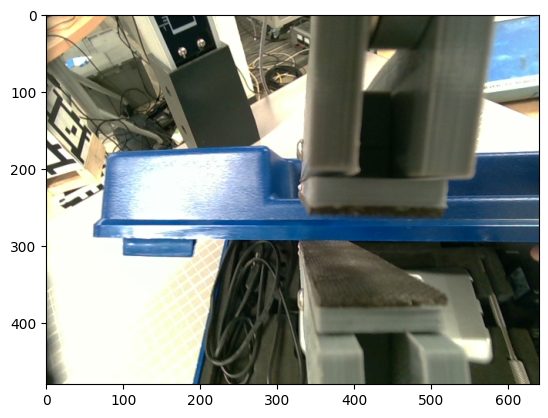

In [33]:
from PIL import Image

im = Image.fromarray(motion_log['record/wrist/']['record/wrist/1744076664.9845352.jpeg'])
import matplotlib.pyplot as plt
plt.imshow(im)

In [35]:
np.save("scalingforce/gripper_log.npy", motion_log['gripper'],allow_pickle=True)
np.save("scalingforce/robot_log.npy", motion_log['robot_log'],allow_pickle=True)
np.save("scalingforce/wrist_log.npy", motion_log['record/wrist/'],allow_pickle=True)
np.save("scalingforce/wkspc_log.npy", motion_log['record/workspace/'],allow_pickle=True)